# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ivanjameslo/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

---
**Lane: Refresh / Content Opportunity Scoring**

**1. Unit of analysis:** The source warehouse table is intended to contain one daily performance record per client, content item, and report date. I will verify this grain, then aggregate March records into one row per client-content item for the feature frame.

**2. Source table:** I will use `fact_content_daily_performance` as my primary source. It contains daily content-performance measurements and data-availability indicators.

**3. Time window:** March 1–31, 2026 is my observation window. I will use March measurements to construct features, with April 2026 as a proposed subsequent outcome window. I will keep June 2026 reserved for later testing.

**4. Target or proxy:** My intended output is a ranked list of pages for content or SEO review. A possible proxy is whether a page experiences a substantial decline in search impressions in a subsequent period. The exact label threshold and coverage requirements will need to be defined and validated before modeling.

**5. Deliberate exclusion:** I will exclude April outcome measurements from the March feature set. These measurements would not be available at the March decision moment. Including them as predictors would introduce target leakage.


In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Import the libraries we will use
import duckdb
from google.colab import userdata
from huggingface_hub import hf_hub_download

# Retrieve the existing token from Colab Secrets
hf_token = userdata.get("HF_TOKEN")

print("Libraries imported.")
print("Hugging Face token available:", bool(hf_token))

Libraries imported.
Hugging Face token available: True


In [11]:
# Download the March 2026 warehouse file
parquet_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename=(
        "fact_content_daily_performance/"
        "month=2026-03/data_0.parquet"
    ),
    repo_type="dataset",
    token=hf_token
)

print("March file downloaded successfully!")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

March file downloaded successfully!


In [13]:
# Open a local DuckDB connection
con = duckdb.connect()

# Read the downloaded March file
march_data = con.execute(
    "SELECT * FROM read_parquet(?) LIMIT 3",
    [parquet_file]
).df()

# Display the first three records
display(march_data)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

---
**Features:** I will use up to five features derived from March 2026 performance data. Candidate signals include search impressions, clicks, click-through rate, average search position, and the number of days with available search data. Each feature must be available by the end of the March observation window.

**Label/Proxy:** A proposed target is whether a content item experiences a substantial decline in search impressions in a subsequent period. This outcome would be calculated separately from the observation-window features, subject to adequate data coverage.

**Context:** `report_date`, `client_hash_id`, and `content_hash_id` define when and to which client-content item a record belongs. They support grouping and validation rather than serving directly as predictive signals.

**Availability:** I will use `gsc_data_available` `IS TRUE` to identify records with available Search Console measurements. I will not assume missing GA4 measurements are zero.

**Excluded:** I will exclude future outcome measurements, label-derived columns, and identifiers from the model's feature set. Including information derived from the label would would introduce leakage and make the model appear more accurate than it acutally is.

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Step 1: Get the column names and data types
column_info = con.execute(
    "DESCRIBE SELECT * FROM read_parquet(?)",
    [parquet_file]
).df()

# Step 2: Display the column information
print("March warehouse columns: ")
display(column_info[["column_name", "column_type"]])

# Step 3: Show the total number of columns
print("Total columns: ", len(column_info))

March warehouse columns: 


,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


Total columns:  31


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

---
# **Query 1 Observation:**
The March file contains 9,841,378 records, all with unique report-date, client, and content-item combinations. No duplicate combinations were found within the file.

# **Query 2 Observation:**
The downloaded March file contains 9,841,378 daily performance records spanning March 1–31, 2026, with all 31 calendar dates represented.

# **Query 3 Obeservation:**
Of the 9,841,378 daily records in the downloaded March file, 3,611,061 have GSC data available, while 6,230,317 are unavailable or not explicitly marked as available.

I will use gsc_data_available IS TRUE when constructing search-performance features. Missing GSC data should not automatically be treated as zero impressions or clicks. Data coverage is a limitation that must be considered when comparing content performance.

# **Five March 2026 Features**
1. `march_impressions` — Total GSC impressions during March. Knowable at the end of the March observation window, after the data has been ingested.
2. `march_clicks` — Total GSC clicks during March. Knowable after March data has been collected.
3. `march_ctr` — Calculated from March clicks and impressions. Knowable using the same observation-window data.
4. `march_avg_position` — Impression-weighted average search position for March. Knowable from the recorded March GSC measurements.
5. `gsc_days_available` — Number of March dates with available GSC data. Knowable from the March availability flags and useful for assessing coverage.

All five features use information from the observation window. No April outcome measurements are included. The intended decision moment is after March data ingestion is complete.

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Query 1: Check the grain of the March data
grain_query = """
SELECT
    COUNT(*) AS total_rows,

    COUNT(DISTINCT (
        report_date,
        client_hash_id,
        content_hash_id
    )) AS unique_records

FROM read_parquet(?)
"""

grain_result = con.execute(grain_query, [parquet_file]).df()
display(grain_result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_records
0,9841378,9841378


In [16]:
# Query 2: Check the row count and date span
date_query = """
SELECT
    COUNT(*) AS total_rows,
    MIN(report_date) AS earliest_date,
    MAX(report_date) AS latest_date,
    COUNT(DISTINCT report_date) AS unique_dates
FROM read_parquet(?)
"""

date_result = con.execute(date_query, [parquet_file]).df()
display(date_result)

,total_rows,earliest_date,latest_date,unique_dates
0,9841378,2026-03-01,2026-03-31,31


In [17]:
# Query 3: Check GSC data availability
availability_query = """
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (
        WHERE gsc_data_available IS TRUE
    ) AS available_rows,

    COUNT(*) FILTER (
        WHERE gsc_data_available IS NOT TRUE
    ) AS unavailable_rows

FROM read_parquet(?)
"""

availability_result = con.execute(availability_query, [parquet_file]).df()
display(availability_result)

,total_rows,available_rows,unavailable_rows
0,9841378,3611061,6230317


In [22]:

# Build our five-feature frame from March 2026

feature_query = """
SELECT
    client_hash_id,
    content_hash_id,

    -- Feature 1: Total March search impressions
    SUM(gsc_impressions) AS march_impressions,

    -- Feature 2: Total March search clicks
    SUM(gsc_clicks) AS march_clicks,

    -- Feature 3: Monthly click-through rate
    SUM(gsc_clicks) * 1.0
        / NULLIF(SUM(gsc_impressions), 0) AS march_ctr,

    -- Feature 4: Impression-weighted average position
    SUM(gsc_sum_position) * 1.0
        / NULLIF(SUM(gsc_impressions), 0) AS march_avg_position,

    -- Feature 5: Number of days with GSC data
    COUNT(DISTINCT report_date) AS gsc_days_available

FROM read_parquet(?)

WHERE gsc_data_available IS TRUE

GROUP BY
    client_hash_id,
    content_hash_id
"""

# Run the SQL query
feature_frame = con.execute(
    feature_query,
    [parquet_file]
).df()

# Display the result
print("Feature frame shape:", feature_frame.shape)

display(feature_frame.head(5))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature frame shape: (176738, 7)


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_ctr,march_avg_position,gsc_days_available
0,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,899.0,1.0,0.001112,5.825362,31
1,client_62f4a7e64f5e0096,content_ac8663da7484669a,34.0,0.0,0.000000,5.941176,17
2,client_62f4a7e64f5e0096,content_d49a012dcb924e31,329.0,0.0,0.000000,5.136778,31
3,client_62f4a7e64f5e0096,content_614baf2af4330bd7,772.0,1.0,0.001295,4.818653,31
4,client_62f4a7e64f5e0096,content_4a1ca0fa5c177e0c,14.0,0.0,0.000000,4.285714,10


# **Deliberate Leakage Experiment**

The honest decision tree, using only five March features, achieved Precision@50 of 0.620 on the test split.

After deliberately adding `impression_change_pct`, which is calculated using April outcome information, Precision@50 increased to 1.000. This increase is misleading because the added feature directly reveals the condition used to construct the decline label.

I removed the leaked column from the final model inputs and retained the honest result of 0.620.

This demonstrates why features must be restricted to information available at the decision moment.

In [23]:
# Find the April 2026 warehouse files

from huggingface_hub import HfApi

api = HfApi()

# Get the dataset's file list
all_files = api.list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    token=hf_token
)

# Keep only April's daily performance Parquet files
april_files = [
    file for file in all_files
    if file.startswith(
        "fact_content_daily_performance/month=2026-04/"
    )
    and file.endswith(".parquet")
]

# Display the available files
print ("April Parquet files found: ", len(april_files))

for file in april_files:
  print(file)

April Parquet files found:  1
fact_content_daily_performance/month=2026-04/data_0.parquet


In [24]:
# Download the April 2026 warehouse file

april_parquet_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename=april_files[0],
    repo_type="dataset",
    token=hf_token
)

print("April file downloaded successfully!")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  134MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

April file downloaded successfully!


In [26]:
# Aggregate April 2026 performance by client and content

april_query = """
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_impressions) AS april_impressions,

    COUNT(DISTINCT report_date) AS april_days_available

FROM read_parquet(?)

WHERE gsc_data_available IS TRUE

GROUP BY
    client_hash_id,
    content_hash_id
"""

# Execute the query using our downloaded April file
april_data = con.execute(
    april_query,
    [april_parquet_file]
).df()

# Display the result
print("April data shape:", april_data.shape)

display(april_data.head(5))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April data shape: (194760, 4)


,client_hash_id,content_hash_id,april_impressions,april_days_available
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,28
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,30
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,30
3,client_62f4a7e64f5e0096,content_3d1dc691a3502105,3068.0,30
4,client_62f4a7e64f5e0096,content_9d28af4f99c5e67b,3896.0,30


In [27]:
# Match March features with April outcomes

matched_data = feature_frame.merge(
    april_data,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

# Keep pages with at least 20 available days in both months
eligible_data = matched_data[
    (matched_data["gsc_days_available"] >= 20)
    & (matched_data["april_days_available"] >= 20)
].copy()

print("March page records:", len(feature_frame))
print("April page records:", len(april_data))
print("Pages found in both months:", len(matched_data))
print("Pages passing the coverage filter:", len(eligible_data))

display(eligible_data.head(5))

March page records: 176738
April page records: 194760
Pages found in both months: 158549
Pages passing the coverage filter: 95633


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_ctr,march_avg_position,gsc_days_available,april_impressions,april_days_available
0,client_62f4a7e64f5e0096,content_2e6360ad20fd7107,899.0,1.0,0.001112,5.825362,31,1027.0,30
2,client_62f4a7e64f5e0096,content_d49a012dcb924e31,329.0,0.0,0.000000,5.136778,31,109.0,28
3,client_62f4a7e64f5e0096,content_614baf2af4330bd7,772.0,1.0,0.001295,4.818653,31,278.0,30
5,client_62f4a7e64f5e0096,content_225dc9235023be5f,488.0,1.0,0.002049,18.657787,31,143.0,26
6,client_62f4a7e64f5e0096,content_babcf791dccc1610,181.0,0.0,0.000000,11.740331,30,66.0,22


## **Important Formula (for step 5):**
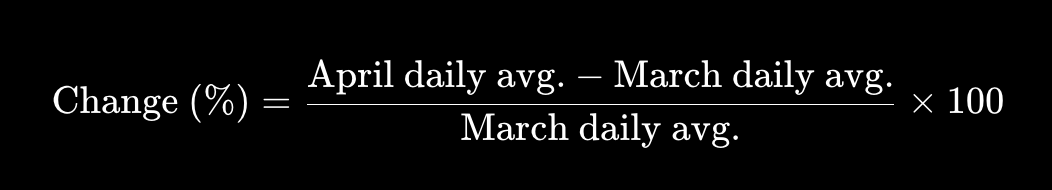

A negative result means average daily impressions fell. A positive result means they increased.

In [28]:
# Step 5: Create our April decline proxy

# 1. Keep pages with positive March impressions
label_data = eligible_data[
    eligible_data["march_impressions"] > 0
].copy()

# 2. Calculate average daily impressions for each month
label_data["march_daily_impressions"] = (
    label_data["march_impressions"]
    / label_data["gsc_days_available"]
)

label_data["april_daily_impressions"] = (
    label_data["april_impressions"]
    / label_data["april_days_available"]
)

# 3. Calculate the percentage change from March to April
label_data["impression_change_pct"] = (
    (
        label_data["april_daily_impressions"]
        - label_data["march_daily_impressions"]
    )
    / label_data["march_daily_impressions"]
) * 100

# 4. Create the binary decline label
label_data["decline_label"] = (
    label_data["impression_change_pct"] < -20
).astype(int)

# 5. Display our results
print("Eligible pages with positive March impressions:", len(label_data))

print("\nDecline label distribution:")
print(label_data["decline_label"].value_counts().sort_index())

display(
    label_data[
        [
            "march_daily_impressions",
            "april_daily_impressions",
            "impression_change_pct",
            "decline_label"
        ]
    ].head(5)
)

Eligible pages with positive March impressions: 95633

Decline label distribution:
decline_label
0    49885
1    45748
Name: count, dtype: int64


,march_daily_impressions,april_daily_impressions,impression_change_pct,decline_label
0,29.000000,34.233333,18.045977,0
2,10.612903,3.892857,-63.319583,1
3,24.903226,9.266667,-62.789292,1
5,15.741935,5.500000,-65.061475,1
6,6.033333,3.000000,-50.276243,1


# **Honest Model**

In [29]:
# Step 6A: Train an honest model using March features only

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score
import numpy as np

# Our five March features
feature_cols = [
    "march_impressions",
    "march_clicks",
    "march_ctr",
    "march_avg_position",
    "gsc_days_available"
]

# Prepare inputs and target
X = label_data[feature_cols].fillna(0)
y = label_data["decline_label"]

# Split the records into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train a small, readable decision tree
honest_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

honest_tree.fit(X_train, y_train)

# Predict decline probabilities for the test records
honest_scores = honest_tree.predict_proba(X_test)[:, 1]

# Calculate Precision@50
top_50_indices = np.argsort(-honest_scores)[:50]

honest_p50 = y_test.iloc[top_50_indices].mean()

print(f"Honest model Precision@50: {honest_p50:.3f}")

Honest model Precision@50: 0.620


# **Introduced Target Leakage**

In [30]:
# Step 6B: Deliberately introduce target leakage

# Add ONE label-derived column to our five March features
leaky_feature_cols = feature_cols + ["impression_change_pct"]

# Create the leaky input data
X_leaky = label_data[leaky_feature_cols].fillna(0)

# Use the SAME train/test rows as our honest experiment
X_leaky_train = X_leaky.loc[X_train.index]
X_leaky_test = X_leaky.loc[X_test.index]

# Train a tree with the leaked feature
leaky_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

leaky_tree.fit(X_leaky_train, y_train)

# Get decline probabilities for the same test records
leaky_scores = leaky_tree.predict_proba(X_leaky_test)[:, 1]

# Calculate Precision@50
leaky_top_50 = np.argsort(-leaky_scores)[:50]

leaky_p50 = y_test.iloc[leaky_top_50].mean()

# Compare both results
print(f"Honest model Precision@50: {honest_p50:.3f}")
print(f"Leaky model Precision@50:  {leaky_p50:.3f}")

Honest model Precision@50: 0.620
Leaky model Precision@50:  1.000


# **Remove the leaked feature**

In [31]:
# Step 6C: Remove the deliberately leaked feature

# Remove the leaked column from our experimental input
X_leaky = X_leaky.drop(
    columns=["impression_change_pct"]
)

# Verify that only our five March features remain
print("Final feature columns:")
print(X_leaky.columns.tolist())

# Keep the honest evaluation result
print(f"\nHonest Precision@50: {honest_p50:.3f}")

# Confirm the leaked column is no longer a model input
assert "impression_change_pct" not in X_leaky.columns

print("Leakage check passed.")

Final feature columns:
['march_impressions', 'march_clicks', 'march_ctr', 'march_avg_position', 'gsc_days_available']

Honest Precision@50: 0.620
Leakage check passed.


## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

---
**Data limitations**

Only 36.7% of daily records in the March 2026 partition had GSC data explicitly available. To avoid treating unavailable measurements as zero, I restricted the feature calculations to records where `gsc_data_available IS TRUE`.

Of the 158,549 client-content combinations found in both March and April, 95,633 (60.3%) passed the requirement of at least 20 available GSC days in each month. The remaining 62,916 were excluded for insufficient coverage.

Even among eligible pages, March coverage ranged from 20 to 31 days, while April coverage ranged from 20 to 30 days. I compared average impressions per available day to account for differences in recorded coverage, but this does not eliminate possible bias from missing dates.

Additionally, the quick leakage experiment used a random row-level train/test split rather than client-holdout validation. Its honest Precision@50 of 0.620 is therefore an illustrative result, not a reliable estimate of performance on unseen clients.



In [32]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Section 4: Check data limitations

# 1. Calculate March GSC availability
total_rows = int(availability_result["total_rows"].iloc[0])
available_rows = int(availability_result["available_rows"].iloc[0])

availability_pct = (available_rows / total_rows) * 100

# 2. Check how many matched pages passed our coverage filter
matched_count = len(matched_data)
eligible_count = len(eligible_data)

excluded_count = matched_count - eligible_count
coverage_pct = (eligible_count / matched_count) * 100

# 3. Check available-day coverage among eligible pages
march_days = eligible_data["gsc_days_available"]
april_days = eligible_data["april_days_available"]

# 4. Display our results
print("DATA LIMITS SUMMARY")
print("-------------------")

print(f"March GSC availability: {availability_pct:.1f}%")

print(f"Pages found in both months: {matched_count:,}")
print(f"Pages passing coverage filter: {eligible_count:,}")
print(f"Pages excluded for insufficient coverage: {excluded_count:,}")

print(f"\nMarch available days: {march_days.min()} to {march_days.max()}")
print(f"April available days: {april_days.min()} to {april_days.max()}")

print(f"\nShare passing coverage filter: {coverage_pct:.1f}%")

DATA LIMITS SUMMARY
-------------------
March GSC availability: 36.7%
Pages found in both months: 158,549
Pages passing coverage filter: 95,633
Pages excluded for insufficient coverage: 62,916

March available days: 20 to 31
April available days: 20 to 30

Share passing coverage filter: 60.3%


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.